# What is Naive Bayes?

**Naive Bayes algorithm is a supervised learning classification algorithm, which is based on Bayes theorem and used for solving classification problems.**

**It predicts the category or class of data based on probabilities.**

It's called "naive" because it assumes that all features (inputs) are independent of each other, which is rarely true in real life. Despite this assumption, it often performs well in practice.

# Key Concepts of Naive Bayes

**1 ) Bayes' Theorem: Bayes' Theorem** is the foundation of Naive Bayes. It helps us calculate the probability of a class (like spam or not spam) given some features (like the words in an email). The formula is:

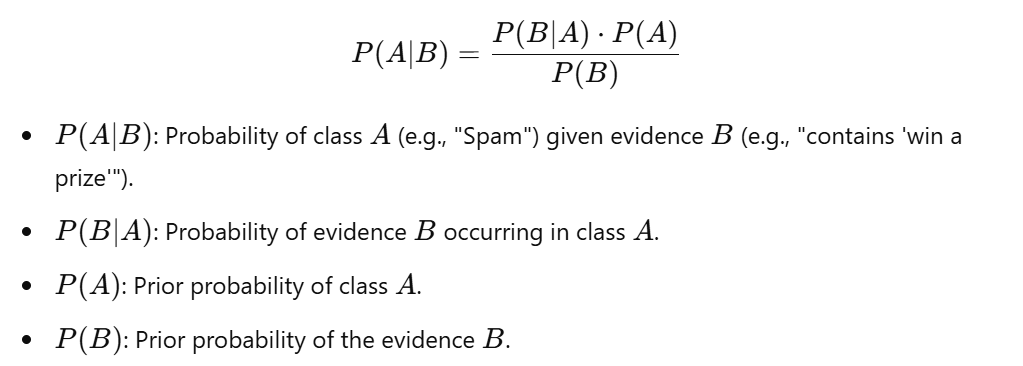

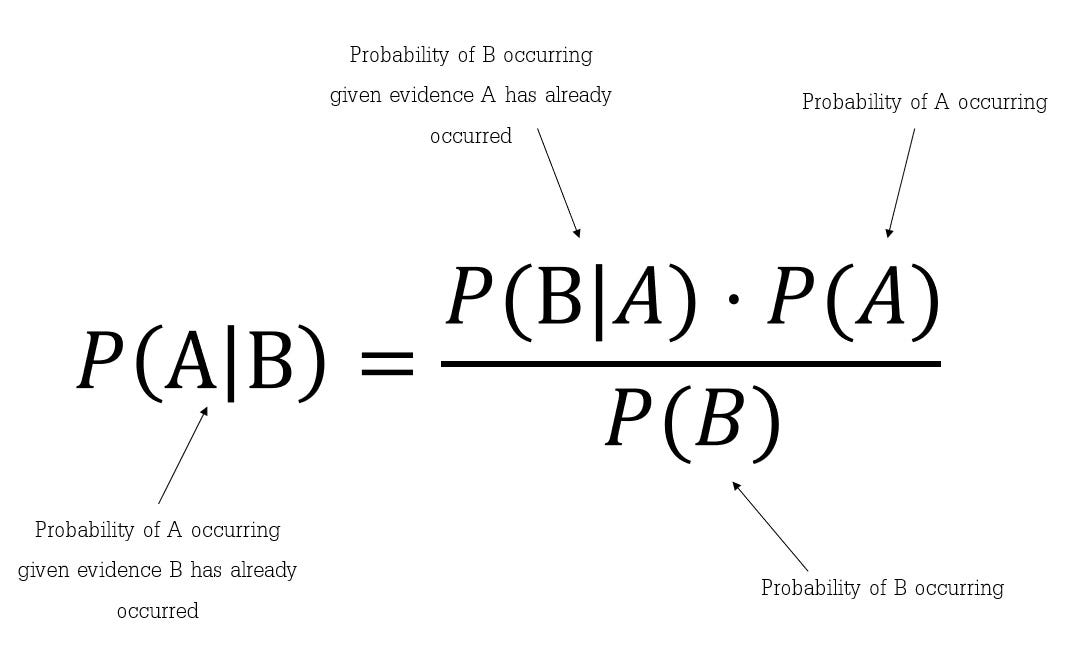


**Bayes’ Theorem is the formula that combines what you knew before and what you just learned to give you a better idea of what’s true. It’s like updating your guess based on new clues.**

**2 ) Why is it "Naive" ?** Naive Bayes assumes that the features are independent of each other. For example, it assumes that if you're classifying emails as spam or not, the presence of the word "win" and the presence of the word "money" are unrelated. This is "naive" because in reality, features are often related.

### Example: Spam Email Classification

Let's classify an email as "Spam" or "Not Spam" based on two words: "win" and "prize".

#### Training Data:
| Email Content           | Spam?     |
|-------------------------|-----------|
| "win a lottery prize"   | Spam      |
| "win big money"         | Spam      |
| "meeting at 3 PM"       | Not Spam  |
| "project submission"    | Not Spam  |

#### Step 1: Calculate Prior Probabilities
- **P(Spam)** = 2/4 = 0.5
- **P(Not Spam)** = 2/4 = 0.5

#### Step 2: Calculate Likelihoods
- **P('win' | Spam)** = 2/2 = 1.0
- **P('prize' | Spam)** = 1/2 = 0.5
- **P('win' | Not Spam)** = 0/2 = 0.0
- **P('prize' | Not Spam)** = 0/2 = 0.0

#### Step 3: Apply Bayes' Theorem

**For a new email: "win a prize"**

##### **1) Calculate P(Spam | Email)**:
P(Spam | Email) ∝ P('win' | Spam) × P('prize' | Spam) × P(Spam)
= 1.0 × 0.5 × 0.5 = 0.25

##### **2) Calculate P(Not Spam | Email)**:
P(Not Spam | Email) ∝ P('win' | Not Spam) × P('prize' | Not Spam) × P(Not Spam)
= 0.0 × 0.0 × 0.5 = 0



#### Step 4: Prediction
Since **P(Spam | Email) > P(Not Spam | Email)**, classify the email as "Spam".



# Advantages of Naive Bayes

# 1) It is the most popular choice for text classification problems.

**2) Fast and Efficient: Works well with large datasets.**

**3) Good with Small Data: Performs well even with less data.**

**4) Handles Multiple Classes: Can easily handle classification with more than two classes.**

# Implementation / Handson

In [ ]:
# Drive : https://drive.google.com/file/d/1C9AuqmgFeh6V67At3347Qspi4BrHU2cJ/view?usp=sharing
# Kaggle link : https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
print(df.isnull().sum().sum())

0


In [ ]:
print(df.duplicated().sum())

1


In [ ]:
# Drop this 1 duplicate records
df.drop_duplicates(inplace=True)

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
# Are we going to check Outliers - No, since its medical data, higher values means serious condition

In [ ]:
x=df.drop("target",axis=1)  # Independent variable
y=df["target"]  # Dependent variable

In [ ]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [ ]:
y

,target
0,1
1,1
2,1
3,1
4,1
...,...
298,0
299,0
300,0
301,0


In [ ]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split( x , y, test_size=0.2 , random_state=0)

In [ ]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import ComplementNB # complementNB - Use with imbalanced data
from sklearn.metrics import *

# GaussianNB

In [ ]:
model1 = GaussianNB()
# Train
model1.fit(x_train , y_train)
# Test
y_pred = model1.predict(x_test)
# Find Accuracy
print("Accuracy score of GaussianNB is :", accuracy_score(y_pred , y_test)*100)

Accuracy score of GaussianNB is : 90.1639344262295


# CategoricalNB

In [ ]:
model1 = CategoricalNB()
# Train
model1.fit(x_train , y_train)
# Test
y_pred = model1.predict(x_test)
# Find Accuracy
print("Accuracy score of CategoricalNB is :", accuracy_score(y_pred , y_test)*100)

Accuracy score of CategoricalNB is : 88.52459016393442


# BernoulliNB

In [ ]:
model1 = BernoulliNB()
# Train
model1.fit(x_train , y_train)
# Test
y_pred = model1.predict(x_test)
# Find Accuracy
print("Accuracy score of BernoulliNB is :", accuracy_score(y_pred , y_test)*100)

Accuracy score of BernoulliNB is : 81.9672131147541


# MultinomialNB

In [ ]:
model1 = MultinomialNB()
# Train
model1.fit(x_train , y_train)
# Test
y_pred = model1.predict(x_test)
# Find Accuracy
print("Accuracy score of MultinomialNB is :", accuracy_score(y_pred , y_test)*100)

Accuracy score of MultinomialNB is : 83.60655737704919


# ComplementNB

In [ ]:
model1 = ComplementNB()
# Train
model1.fit(x_train , y_train)
# Test
y_pred = model1.predict(x_test)
# Find Accuracy
print("Accuracy score of ComplementNB is :", accuracy_score(y_pred , y_test)*100)

Accuracy score of ComplementNB is : 83.60655737704919


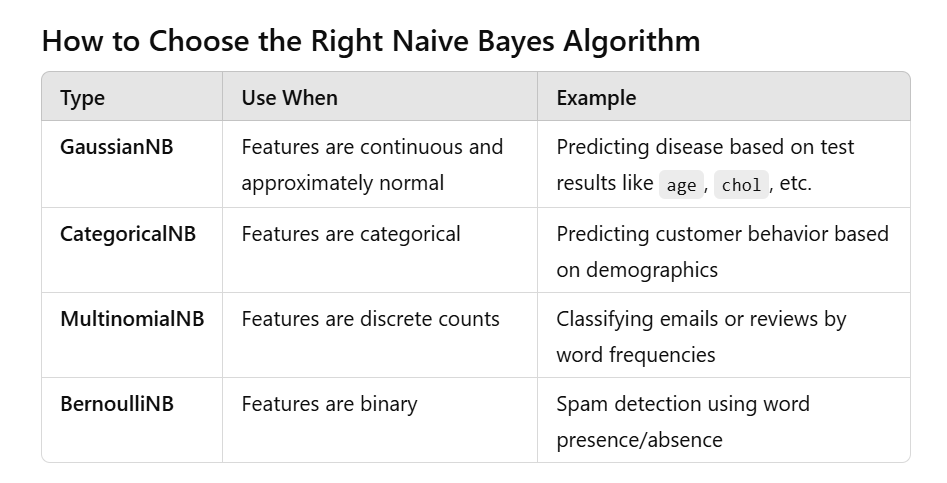